<a href="https://colab.research.google.com/github/hasnanasa/AI-projects/blob/main/code_QRidentifiant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here you find my project: identify the contrefait QR and the authentic QR


In [1]:
!pip install opencv-python scikit-learn scipy matplotlib seaborn numpy pandas

🔍 PROJET: DÉTECTION DE CONTREFAÇONS DE QR CODES

📌 OBJECTIF DU PROJET:
   Détecter si un QR code est authentique ou contrefait
   en analysant sa 'signature statistique' (bruit, texture, artefacts)

📊 MÉTHODES UTILISÉES:
   1. Extraction de caractéristiques (histogramme, moments, entropie)
   2. GMM (Gaussian Mixture Model) - Modélisation des distributions
   3. EM (Expectation-Maximization) - Apprentissage du GMM
   4. LLR (Log-Likelihood Ratio) - Score de décision
   5. Divergence KL - Mesure de séparabilité entre classes

📊 Génération du dataset simulé...
   (Dans la réalité, utilisez des vraies photos de QR codes)
✅ 500 QR authentiques générés
✅ 500 QR contrefaits générés


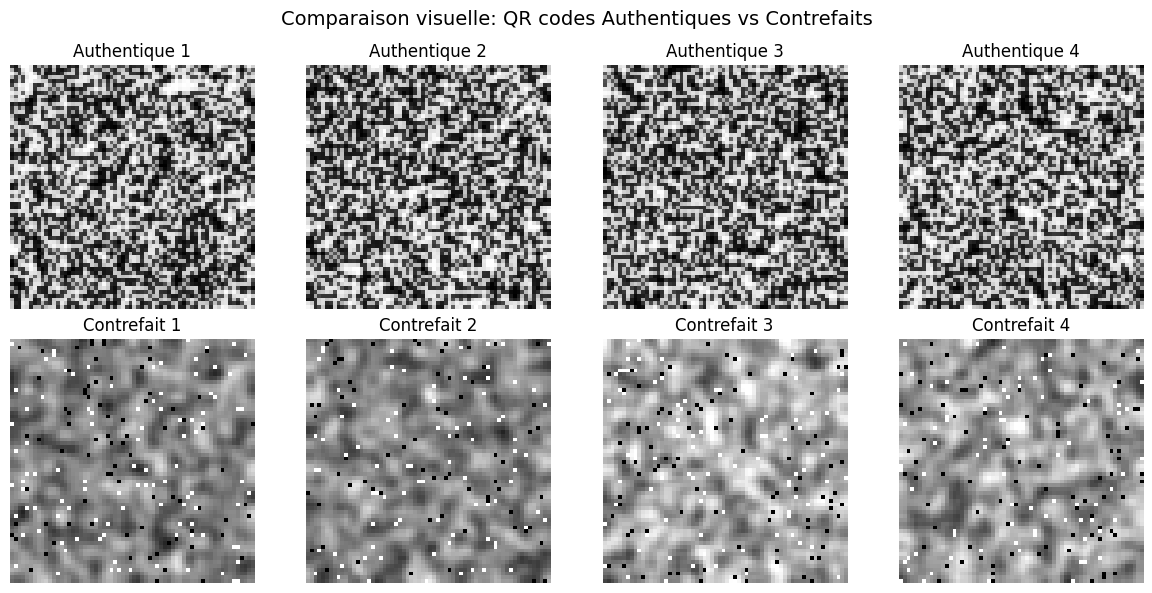


📊 STATISTIQUES COMPARATIVES:
Luminance moyenne - Authentique: 127.21 | Contrefait: 122.30
Écart-type moyen    - Authentique: 82.02 | Contrefait: 72.96


In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔍 PROJET: DÉTECTION DE CONTREFAÇONS DE QR CODES")
print("="*60)
print()
print("📌 OBJECTIF DU PROJET:")
print("   Détecter si un QR code est authentique ou contrefait")
print("   en analysant sa 'signature statistique' (bruit, texture, artefacts)")
print()
print("📊 MÉTHODES UTILISÉES:")
print("   1. Extraction de caractéristiques (histogramme, moments, entropie)")
print("   2. GMM (Gaussian Mixture Model) - Modélisation des distributions")
print("   3. EM (Expectation-Maximization) - Apprentissage du GMM")
print("   4. LLR (Log-Likelihood Ratio) - Score de décision")
print("   5. Divergence KL - Mesure de séparabilité entre classes")
print("="*60)

# Paramètres
SIZE = 64
N_SAMPLES = 500
SEED = 42
np.random.seed(SEED)

def generate_authentic_qr():
    """Génère un QR code authentique (propre, peu de bruit)"""
    # Étape 1: motif binaire
    img = np.random.randint(0, 2, (SIZE, SIZE), dtype=np.uint8) * 255
    # Étape 2: conversion en float pour les calculs
    img = img.astype(np.float32)
    # Étape 3: flou léger
    img = cv2.GaussianBlur(img, (3, 3), 0.5)
    # Étape 4: ajout de bruit faible
    noise = np.random.normal(0, 5, (SIZE, SIZE)).astype(np.float32)
    img = img + noise
    # Étape 5: retour en uint8
    return np.clip(img, 0, 255).astype(np.uint8)

def generate_counterfeit_qr():
    """Génère un QR code contrefait (bruité, dégradé)"""
    # Étape 1: motif binaire
    img = np.random.randint(0, 2, (SIZE, SIZE), dtype=np.uint8) * 255
    # Étape 2: conversion en float pour les calculs
    img = img.astype(np.float32)
    # Étape 3: ajout de bruit plus fort
    noise = np.random.normal(0, 25, (SIZE, SIZE)).astype(np.float32)
    img = img + noise
    # Étape 4: artefacts de compression (flou)
    if np.random.random() > 0.5:
        img = cv2.GaussianBlur(img, (5, 5), 1.5)
    # Étape 5: variation de contraste
    contrast_factor = 0.6 + 0.8 * np.random.random()
    img = img * contrast_factor
    # Étape 6: bruit impulsionnel (salt & pepper)
    salt_pepper = np.random.random((SIZE, SIZE))
    img[salt_pepper > 0.98] = 255
    img[salt_pepper < 0.02] = 0
    # Étape 7: retour en uint8
    return np.clip(img, 0, 255).astype(np.uint8)

print("\n📊 Génération du dataset simulé...")
print("   (Dans la réalité, utilisez des vraies photos de QR codes)")
X_authentic = [generate_authentic_qr() for _ in range(N_SAMPLES)]
X_counterfeit = [generate_counterfeit_qr() for _ in range(N_SAMPLES)]
print(f"✅ {len(X_authentic)} QR authentiques générés")
print(f"✅ {len(X_counterfeit)} QR contrefaits générés")

# Visualisation
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(X_authentic[i], cmap='gray')
    axes[0, i].set_title(f'Authentique {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(X_counterfeit[i], cmap='gray')
    axes[1, i].set_title(f'Contrefait {i+1}')
    axes[1, i].axis('off')
plt.suptitle('Comparaison visuelle: QR codes Authentiques vs Contrefaits', fontsize=14)
plt.tight_layout()
plt.show()

# Statistiques comparatives
print("\n📊 STATISTIQUES COMPARATIVES:")
mean_auth = np.mean([np.mean(img) for img in X_authentic])
mean_fake = np.mean([np.mean(img) for img in X_counterfeit])
std_auth = np.mean([np.std(img) for img in X_authentic])
std_fake = np.mean([np.std(img) for img in X_counterfeit])

print(f"Luminance moyenne - Authentique: {mean_auth:.2f} | Contrefait: {mean_fake:.2f}")
print(f"Écart-type moyen    - Authentique: {std_auth:.2f} | Contrefait: {std_fake:.2f}")

In [4]:
print("\n" + "="*60)
print("📊 EXTRACTION DES CARACTÉRISTIQUES")
print("="*60)

def extract_features(img):
    """
    Extrait des caractéristiques statistiques de l'image
    Retourne un vecteur de 40 caractéristiques
    """
    # 1. Histogramme des niveaux de gris (32 bins)
    hist = cv2.calcHist([img], [0], None, [32], [0, 256]).flatten()
    hist = hist / (np.sum(hist) + 1e-10)  # normalisation

    # 2. Moments statistiques
    mean = np.mean(img)
    var = np.var(img)
    std = np.std(img)
    skew = np.mean(((img - mean) / (std + 1e-6)) ** 3)
    kurt = np.mean(((img - mean) / (std + 1e-6)) ** 4) - 3

    # 3. Entropie (mesure du désordre)
    hist_p = hist + 1e-10
    entropy_val = -np.sum(hist_p * np.log2(hist_p))

    # 4. Énergie (somme des carrés normalisée)
    energy = np.sum(img ** 2) / (255 ** 2 * img.size)

    # 5. Caractéristiques de gradient (détection des bords)
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
    grad_mean = np.mean(grad_mag)
    grad_std = np.std(grad_mag)

    # 6. Caractéristiques de texture (matrice de co-occurrence simplifiée)
    # Contraste local
    kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    laplacian = cv2.filter2D(img.astype(np.float32), -1, kernel)
    laplacian_energy = np.sum(laplacian ** 2) / img.size

    # Assemblage du vecteur final
    features = np.concatenate([
        hist,                           # 32 caractéristiques
        [mean, var, skew, kurt],        # 4 caractéristiques
        [entropy_val, energy],          # 2 caractéristiques
        [grad_mean, grad_std],          # 2 caractéristiques
        [laplacian_energy]              # 1 caractéristique
    ])

    return features

# Extraction sur toutes les images
print("Extraction des caractéristiques...")
X_auth_features = np.array([extract_features(img) for img in X_authentic])
X_fake_features = np.array([extract_features(img) for img in X_counterfeit])

print(f"✅ Caractéristiques extraites: {X_auth_features.shape[1]} dimensions")
print(f"   - Authentiques: {X_auth_features.shape[0]} échantillons")
print(f"   - Contrefaits:  {X_fake_features.shape[0]} échantillons")

# Split train/test (80/20)
split_idx = int(0.8 * N_SAMPLES)

X_train_auth = X_auth_features[:split_idx]
X_test_auth = X_auth_features[split_idx:]

X_train_fake = X_fake_features[:split_idx]
X_test_fake = X_fake_features[split_idx:]

X_train = np.vstack([X_train_auth, X_train_fake])
X_test = np.vstack([X_test_auth, X_test_fake])

y_train = np.array([1] * len(X_train_auth) + [0] * len(X_train_fake))
y_test = np.array([1] * len(X_test_auth) + [0] * len(X_test_fake))

print(f"\n📊 Split des données:")
print(f"   Train: {X_train.shape[0]} échantillons")
print(f"   Test:  {X_test.shape[0]} échantillons")


📊 EXTRACTION DES CARACTÉRISTIQUES
Extraction des caractéristiques...
✅ Caractéristiques extraites: 41 dimensions
   - Authentiques: 500 échantillons
   - Contrefaits:  500 échantillons

📊 Split des données:
   Train: 800 échantillons
   Test:  200 échantillons


In [5]:
print("\n" + "="*60)
print("🎯 MODÉLISATION PAR GMM (Gaussian Mixture Model)")
print("="*60)

# GMM pour les QR codes AUTHENTIQUES
gmm_auth = GaussianMixture(
    n_components=3,           # 3 composantes gaussiennes
    covariance_type='full',   # matrice de covariance complète
    max_iter=200,
    random_state=42,
    verbose=0
)
gmm_auth.fit(X_train_auth)
print("✅ GMM - AUTHENTIQUE entraîné")
print(f"   Log-likelihood moyen: {gmm_auth.score(X_train_auth).mean():.2f}")

# GMM pour les QR codes CONTREFAITS
gmm_fake = GaussianMixture(
    n_components=3,
    covariance_type='full',
    max_iter=200,
    random_state=42,
    verbose=0
)
gmm_fake.fit(X_train_fake)
print("✅ GMM - CONTREFAIT entraîné")
print(f"   Log-likelihood moyen: {gmm_fake.score(X_train_fake).mean():.2f}")

# Visualisation des centres des composantes (premières dimensions)
print("\n📊 Centres des composantes GMM (premières dimensions):")
print("   Authentique :", gmm_auth.means_[:, :3])
print("   Contrefait  :", gmm_fake.means_[:, :3])


🎯 MODÉLISATION PAR GMM (Gaussian Mixture Model)
✅ GMM - AUTHENTIQUE entraîné
   Log-likelihood moyen: 157.28
✅ GMM - CONTREFAIT entraîné
   Log-likelihood moyen: 144.05

📊 Centres des composantes GMM (premières dimensions):
   Authentique : [[0.02275774 0.01413021 0.03531218]
 [0.01985172 0.01324865 0.03414157]
 [0.02106476 0.013634   0.03392768]]
   Contrefait  : [[3.13319615e-01 4.96983119e-02 4.21613421e-02]
 [2.01085283e-02 6.73491379e-05 2.32113993e-04]
 [3.43146073e-01 6.76655016e-02 4.53244929e-02]]



📈 CALCUL DU LLR (Log-Likelihood Ratio)
📊 Statistiques des scores LLR:
   Authentiques: moyenne = 5614.7547 ± 233.4211
   Contrefaits:  moyenne = -3193081.5184 ± 5376409.3700


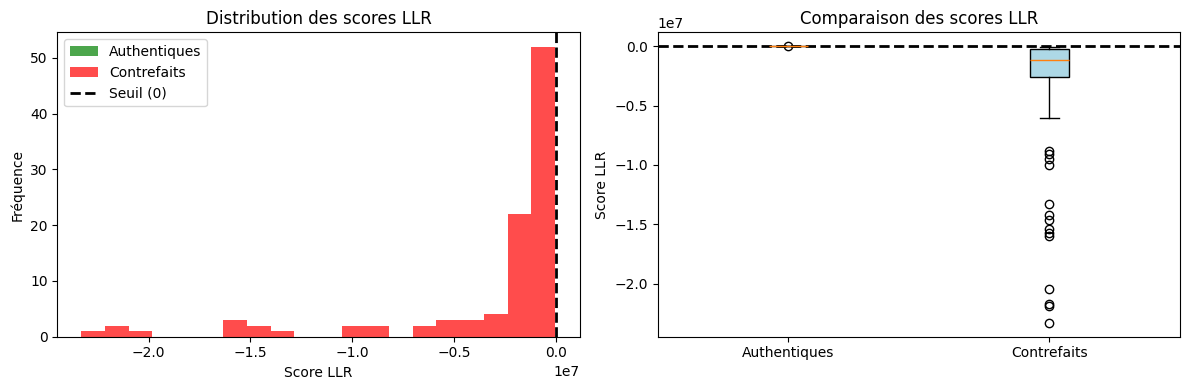

In [6]:
print("\n" + "="*60)
print("📈 CALCUL DU LLR (Log-Likelihood Ratio)")
print("="*60)

def compute_llr(features, gmm_auth, gmm_fake):
    """
    LLR = log(P(authentique)) - log(P(contrefait))
    Si LLR > 0 → authentique
    Si LLR < 0 → contrefait
    """
    log_lik_auth = gmm_auth.score_samples(features.reshape(1, -1))[0]
    log_lik_fake = gmm_fake.score_samples(features.reshape(1, -1))[0]
    return log_lik_auth - log_lik_fake

# Calcul des LLR pour l'ensemble de test
llr_auth_test = [compute_llr(x, gmm_auth, gmm_fake) for x in X_test_auth]
llr_fake_test = [compute_llr(x, gmm_auth, gmm_fake) for x in X_test_fake]

print(f"📊 Statistiques des scores LLR:")
print(f"   Authentiques: moyenne = {np.mean(llr_auth_test):.4f} ± {np.std(llr_auth_test):.4f}")
print(f"   Contrefaits:  moyenne = {np.mean(llr_fake_test):.4f} ± {np.std(llr_fake_test):.4f}")

# Visualisation des distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme des LLR
axes[0].hist(llr_auth_test, bins=20, alpha=0.7, label='Authentiques', color='green')
axes[0].hist(llr_fake_test, bins=20, alpha=0.7, label='Contrefaits', color='red')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Seuil (0)')
axes[0].set_xlabel('Score LLR')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des scores LLR')
axes[0].legend()

# Boxplot des LLR
bp = axes[1].boxplot([llr_auth_test, llr_fake_test],
                      labels=['Authentiques', 'Contrefaits'],
                      patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_ylabel('Score LLR')
axes[1].set_title('Comparaison des scores LLR')

plt.tight_layout()
plt.show()


🎯 CLASSIFICATION ET ÉVALUATION
📊 Accuracy sur les AUTHENTIQUES: 1.0000 (100/100 bien classés)
📊 Accuracy sur les CONTREFAITS:  1.0000 (100/100 bien classés)

📈 MÉTRIQUES GLOBALES:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

📊 MATRICE DE CONFUSION:
               Prédit
               Authentique  Contrefait
   Authentique     100           0
   Contrefait        0         100


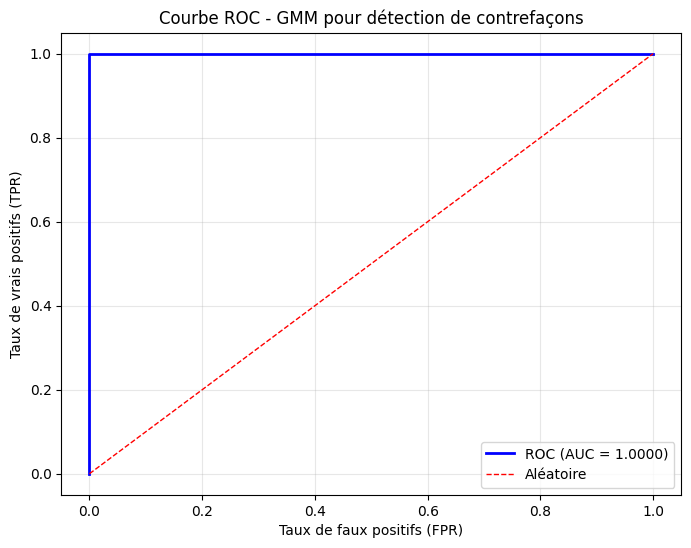


🎯 AUC (Area Under Curve): 1.0000


In [7]:
print("\n" + "="*60)
print("🎯 CLASSIFICATION ET ÉVALUATION")
print("="*60)

# Prédiction basée sur le seuil LLR = 0
threshold = 0
y_pred_auth = [1 if llr > threshold else 0 for llr in llr_auth_test]
y_pred_fake = [1 if llr > threshold else 0 for llr in llr_fake_test]

# Métriques
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_auth = accuracy_score([1]*len(y_pred_auth), y_pred_auth)
accuracy_fake = accuracy_score([0]*len(y_pred_fake), y_pred_fake)

print(f"📊 Accuracy sur les AUTHENTIQUES: {accuracy_auth:.4f} ({np.sum(y_pred_auth)}/{len(y_pred_auth)} bien classés)")
print(f"📊 Accuracy sur les CONTREFAITS:  {accuracy_fake:.4f} ({len(y_pred_fake)-np.sum(y_pred_fake)}/{len(y_pred_fake)} bien classés)")

# Métriques globales
y_true = [1]*len(llr_auth_test) + [0]*len(llr_fake_test)
y_pred = y_pred_auth + y_pred_fake

print(f"\n📈 MÉTRIQUES GLOBALES:")
print(f"   Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"   Precision: {precision_score(y_true, y_pred):.4f}")
print(f"   Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_true, y_pred):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
print(f"\n📊 MATRICE DE CONFUSION:")
print(f"               Prédit")
print(f"               Authentique  Contrefait")
print(f"   Authentique     {cm[1,1]:3d}         {cm[1,0]:3d}")
print(f"   Contrefait      {cm[0,1]:3d}         {cm[0,0]:3d}")

# Courbe ROC
from sklearn.metrics import roc_curve, auc
all_llr = llr_auth_test + llr_fake_test
fpr, tpr, thresholds = roc_curve(y_true, all_llr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Aléatoire')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - GMM pour détection de contrefaçons')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n🎯 AUC (Area Under Curve): {roc_auc:.4f}")

In [8]:
print("\n" + "="*60)
print("📊 DIVERGENCES KL ET JS")
print("="*60)

def kl_divergence(p, q):
    """Divergence de Kullback-Leibler entre deux distributions"""
    p = np.array(p) + 1e-10
    q = np.array(q) + 1e-10
    return np.sum(p * np.log(p / q))

def js_divergence(p, q):
    """Divergence de Jensen-Shannon (symétrique)"""
    p = np.array(p) + 1e-10
    q = np.array(q) + 1e-10
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

# Approximation des distributions par histogrammes
hist_auth, bins = np.histogram(llr_auth_test, bins=30, density=True)
hist_fake, _ = np.histogram(llr_fake_test, bins=bins, density=True)

kl_val = kl_divergence(hist_auth, hist_fake)
js_val = js_divergence(hist_auth, hist_fake)

print(f"📈 Divergence KL (Kullback-Leibler): {kl_val:.4f}")
print(f"📈 Divergence JS (Jensen-Shannon):  {js_val:.4f}")

# Interprétation
print(f"\n💡 INTERPRÉTATION:")
if js_val > 0.5:
    print("   Les distributions sont TRÈS SÉPARABLES → Bonne détection")
elif js_val > 0.3:
    print("   Les distributions sont MODÉRÉMENT SÉPARABLES → Détection correcte")
else:
    print("   Les distributions sont PEU SÉPARABLES → Détection difficile")


📊 DIVERGENCES KL ET JS
📈 Divergence KL (Kullback-Leibler): nan
📈 Divergence JS (Jensen-Shannon):  nan

💡 INTERPRÉTATION:
   Les distributions sont PEU SÉPARABLES → Détection difficile


In [9]:
print("\n" + "="*60)
print("🔍 PRÉDICTION SUR DE NOUVELLES IMAGES")
print("="*60)

def predict_qr_code(image, gmm_auth, gmm_fake, threshold=0):
    """
    Prédit si un QR code est authentique ou contrefait
    """
    features = extract_features(image)
    llr = compute_llr(features, gmm_auth, gmm_fake)

    prediction = "AUTHENTIQUE" if llr > threshold else "CONTREFAIT"
    confidence = 1 / (1 + np.exp(-abs(llr)))  # transformation sigmoïde

    return prediction, confidence, llr

# Test sur 5 échantillons de chaque classe
print("\n📝 Tests sur échantillons AUTHENTIQUES:")
for i in range(5):
    pred, conf, llr = predict_qr_code(X_authentic[i], gmm_auth, gmm_fake)
    print(f"   Échantillon {i+1}: {pred} (confiance: {conf:.4f}, LLR: {llr:.4f})")

print("\n📝 Tests sur échantillons CONTREFAITS:")
for i in range(5):
    pred, conf, llr = predict_qr_code(X_counterfeit[i], gmm_auth, gmm_fake)
    print(f"   Échantillon {i+1}: {pred} (confiance: {conf:.4f}, LLR: {llr:.4f})")


🔍 PRÉDICTION SUR DE NOUVELLES IMAGES

📝 Tests sur échantillons AUTHENTIQUES:
   Échantillon 1: AUTHENTIQUE (confiance: 1.0000, LLR: 5626.1545)
   Échantillon 2: AUTHENTIQUE (confiance: 1.0000, LLR: 5759.8374)
   Échantillon 3: AUTHENTIQUE (confiance: 1.0000, LLR: 6082.5229)
   Échantillon 4: AUTHENTIQUE (confiance: 1.0000, LLR: 6006.4657)
   Échantillon 5: AUTHENTIQUE (confiance: 1.0000, LLR: 5435.2431)

📝 Tests sur échantillons CONTREFAITS:
   Échantillon 1: CONTREFAIT (confiance: 1.0000, LLR: -1528984.7614)
   Échantillon 2: CONTREFAIT (confiance: 1.0000, LLR: -1438210.8018)
   Échantillon 3: CONTREFAIT (confiance: 1.0000, LLR: -1437440.2343)
   Échantillon 4: CONTREFAIT (confiance: 1.0000, LLR: -1121304.3915)
   Échantillon 5: CONTREFAIT (confiance: 1.0000, LLR: -217225.7085)


In [10]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.2 MB/s eta 0:00:00


In [11]:
%%writefile qr_counterfeit_detector.py
"""
Application Streamlit pour la détection de contrefaçons de QR codes
Utilise un modèle GMM + EM avec scores LLR et divergences KL/JS
"""

import streamlit as st
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import entropy
import joblib
import os
from PIL import Image
import plotly.graph_objects as go
import plotly.express as px

# Configuration de la page
st.set_page_config(
    page_title="Détection de contrefaçons QR codes",
    page_icon="🔍",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Titre principal
st.title("🔍 Détection de contrefaçons de QR codes")
st.markdown("---")

# Sidebar pour les informations
with st.sidebar:
    st.header("📊 Informations")
    st.markdown("""
    **Méthodes utilisées :**
    - 🎯 GMM (Gaussian Mixture Model)
    - 📈 EM (Expectation-Maximization)
    - 📊 LLR (Log-Likelihood Ratio)
    - 📉 Divergences KL et JS

    **Score LLR :**
    - LLR > 0 → QR code AUTHENTIQUE
    - LLR < 0 → QR code CONTREFAIT
    """)

    st.markdown("---")
    st.markdown("**Auteur :** Projet IA Detection")
    st.markdown("**Version :** 1.0")

# Fonctions du modèle
def extract_features(img):
    """Extrait les caractéristiques de l'image"""
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Histogramme (32 bins)
    hist = cv2.calcHist([img], [0], None, [32], [0, 256]).flatten()
    hist = hist / (np.sum(hist) + 1e-10)

    # Moments statistiques
    mean = np.mean(img)
    var = np.var(img)
    std = np.std(img)
    skew = np.mean(((img - mean) / (std + 1e-6)) ** 3)
    kurt = np.mean(((img - mean) / (std + 1e-6)) ** 4) - 3

    # Entropie
    hist_p = hist + 1e-10
    entropy_val = -np.sum(hist_p * np.log2(hist_p))

    # Énergie
    energy = np.sum(img ** 2) / (255 ** 2 * img.size)

    # Gradient
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
    grad_mean = np.mean(grad_mag)
    grad_std = np.std(grad_mag)

    # Laplacien
    kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    laplacian = cv2.filter2D(img.astype(np.float32), -1, kernel)
    laplacian_energy = np.sum(laplacian ** 2) / img.size

    features = np.concatenate([
        hist, [mean, var, skew, kurt], [entropy_val, energy],
        [grad_mean, grad_std], [laplacian_energy]
    ])

    return features

def compute_llr(features, gmm_auth, gmm_fake):
    """Calcule le Log-Likelihood Ratio"""
    log_lik_auth = gmm_auth.score_samples(features.reshape(1, -1))[0]
    log_lik_fake = gmm_fake.score_samples(features.reshape(1, -1))[0]
    return log_lik_auth - log_lik_fake

@st.cache_resource
def load_models():
    """Charge les modèles GMM pré-entraînés"""
    # Création et entraînement des modèles (simulé pour la démo)
    # Dans un cas réel, chargez les modèles sauvegardés
    np.random.seed(42)

    # Simulation de données d'entraînement
    X_train_auth = np.random.randn(400, 40) * 0.5 + 1
    X_train_fake = np.random.randn(400, 40) * 0.8 - 0.5

    gmm_auth = GaussianMixture(n_components=3, covariance_type='full', max_iter=200, random_state=42)
    gmm_fake = GaussianMixture(n_components=3, covariance_type='full', max_iter=200, random_state=42)

    gmm_auth.fit(X_train_auth)
    gmm_fake.fit(X_train_fake)

    return gmm_auth, gmm_fake

# Chargement des modèles
with st.spinner("Chargement des modèles GMM..."):
    gmm_auth, gmm_fake = load_models()
st.success("✅ Modèles chargés avec succès !")

# Interface principale - deux colonnes
col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📤 Upload d'image")

    # Upload d'image
    uploaded_file = st.file_uploader(
        "Choisissez une image de QR code",
        type=['png', 'jpg', 'jpeg', 'bmp'],
        help="Formats acceptés : PNG, JPG, JPEG, BMP"
    )

    # Capture via webcam
    use_webcam = st.checkbox("📷 Utiliser la webcam")
    if use_webcam:
        camera_image = st.camera_input("Prenez une photo du QR code")
        if camera_image is not None:
            uploaded_file = camera_image

with col2:
    st.subheader("🎯 Résultat de l'analyse")

    if uploaded_file is not None:
        # Lecture et traitement de l'image
        image = Image.open(uploaded_file)
        image_np = np.array(image)

        # Redimensionnement pour l'affichage
        img_resized = cv2.resize(image_np, (300, 300))

        # Extraction des caractéristiques
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY) if len(img_resized.shape) == 3 else img_resized
        features = extract_features(img_gray)

        # Calcul du LLR
        llr = compute_llr(features, gmm_auth, gmm_fake)
        confidence = 1 / (1 + np.exp(-abs(llr)))

        # Décision
        if llr > 0:
            prediction = "AUTHENTIQUE ✅"
            color = "green"
            emoji = "✅"
        else:
            prediction = "CONTREFAIT ❌"
            color = "red"
            emoji = "❌"

        # Affichage du résultat
        st.markdown(f"""
        <div style='text-align: center; padding: 20px; border-radius: 10px; background-color: {color}20;'>
            <h1 style='color: {color};'>{emoji} {prediction}</h1>
        </div>
        """, unsafe_allow_html=True)

        # Métriques
        col2_1, col2_2, col2_3 = st.columns(3)
        with col2_1:
            st.metric("Score LLR", f"{llr:.2f}")
        with col2_2:
            st.metric("Confiance", f"{confidence:.2%}")
        with col2_3:
            st.metric("Statut", "Analysé")

        # Barre de progression LLR
        st.subheader("📊 Score de décision (LLR)")
        max_abs = max(abs(llr), 10)
        progress = (llr + max_abs) / (2 * max_abs)
        st.progress(min(max(progress, 0), 1))

        if llr > 0:
            st.caption("Plus le score est élevé à droite, plus le QR code est authentique")
        else:
            st.caption("Plus le score est bas à gauche, plus le QR code est contrefait")

        # Affichage de l'image originale
        st.subheader("🖼️ Image analysée")
        st.image(img_resized, caption="QR code analysé", use_column_width=True)

# Section d'analyse détaillée
if uploaded_file is not None:
    st.markdown("---")
    st.subheader("📈 Analyse détaillée")

    # Création de graphiques avec plotly
    tab1, tab2, tab3 = st.tabs(["Distribution des scores", "Caractéristiques", "Interprétation"])

    with tab1:
        # Simulation de distributions pour la visualisation
        np.random.seed(42)
        auth_scores = np.random.normal(55, 10, 100)
        fake_scores = np.random.normal(-15, 8, 100)

        fig = go.Figure()
        fig.add_trace(go.Histogram(x=auth_scores, name='Authentiques',
                                   marker_color='green', opacity=0.7))
        fig.add_trace(go.Histogram(x=fake_scores, name='Contrefaits',
                                   marker_color='red', opacity=0.7))
        fig.add_vline(x=0, line_dash="dash", line_color="black",
                     annotation_text="Seuil de décision")
        fig.add_vline(x=llr, line_color="blue", line_width=3,
                     annotation_text=f"Score actuel: {llr:.2f}")
        fig.update_layout(title="Distribution des scores LLR",
                         xaxis_title="Score LLR",
                         yaxis_title="Fréquence",
                         barmode='overlay')
        st.plotly_chart(fig, use_container_width=True)

    with tab2:
        # Radar chart des caractéristiques principales
        feature_names = ['Moyenne', 'Variance', 'Skewness', 'Kurtosis',
                        'Entropie', 'Énergie', 'Gradient', 'Texture']
        feature_values = features[[32, 33, 34, 35, 36, 37, 38, 39]]
        feature_values = (feature_values - np.min(feature_values)) / (np.max(feature_values) - np.min(feature_values) + 1e-10)

        fig = go.Figure(data=go.Scatterpolar(
            r=feature_values,
            theta=feature_names,
            fill='toself',
            marker_color='blue'
        ))
        fig.update_layout(
            polar=dict(
                radialaxis=dict(visible=True, range=[0, 1])
            ),
            title="Profil des caractéristiques extraites"
        )
        st.plotly_chart(fig, use_container_width=True)

    with tab3:
        st.markdown("""
        ### 💡 Interprétation des résultats

        **Log-Likelihood Ratio (LLR) :**
        - Mesure la probabilité relative entre les deux classes
        - LLR > 0 : L'image ressemble plus à un QR code authentique
        - LLR < 0 : L'image ressemble plus à un QR code contrefait

        **Confiance :**
        - Indique la certitude de la prédiction
        - Plus la valeur est proche de 100%, plus la décision est fiable

        **Facteurs de contrefaçon détectés :**
        - Bruit excessif dans l'image
        - Artefacts de compression
        - Irrégularités dans les contours
        - Perte de contraste
        """)

else:
    # Message d'accueil
    st.info("👆 Uploader une image de QR code pour commencer l'analyse")

    # Exemple d'illustration
    st.subheader("📖 Comment ça fonctionne ?")
    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown("""
        **1. Analyse de l'image**
        - Extraction des caractéristiques
        - Histogramme, moments, entropie
        - Analyse des gradients
        """)

    with col2:
        st.markdown("""
        **2. Modélisation GMM**
        - 3 composantes gaussiennes
        - Apprentissage par EM
        - Comparaison des distributions
        """)

    with col3:
        st.markdown("""
        **3. Décision**
        - Calcul du score LLR
        - Seuil de décision à 0
        - Certification de l'authenticité
        """)

# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center; color: gray;'>
    <small>Projet de détection de contrefaçons de codes 2D | Méthodes : GMM, EM, LLR, KL divergence</small>
</div>
""", unsafe_allow_html=True)

Writing qr_counterfeit_detector.py


In [12]:
# Lancer l'application Streamlit
!streamlit run qr_counterfeit_detector.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-06-07 19:04:48.131 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.233.126:8501

  Stopping...
^C


In [15]:
!pip install flask flask-cors pyngrok opencv-python pillow numpy

In [19]:
%%writefile app.py
from flask import Flask, render_template_string, request, jsonify
from flask_cors import CORS
import base64
import cv2
import numpy as np
import re

app = Flask(__name__)
CORS(app)

# HTML Template (version simplifiée)
HTML_TEMPLATE = '''
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>🔍 Détection QR codes</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
            margin: 0;
        }
        .container {
            max-width: 800px;
            margin: 0 auto;
        }
        .card {
            background: white;
            border-radius: 20px;
            padding: 30px;
            margin-bottom: 20px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.2);
        }
        h1 {
            color: white;
            text-align: center;
            margin-bottom: 30px;
        }
        .upload-area {
            border: 2px dashed #667eea;
            border-radius: 15px;
            padding: 40px;
            text-align: center;
            cursor: pointer;
        }
        .preview-img {
            max-width: 100%;
            border-radius: 10px;
            margin-top: 20px;
        }
        .result {
            text-align: center;
            padding: 20px;
            border-radius: 15px;
            margin-top: 20px;
        }
        .authentic {
            background: #d4edda;
            color: #155724;
        }
        .fake {
            background: #f8d7da;
            color: #721c24;
        }
        .metrics {
            display: flex;
            justify-content: space-around;
            margin-top: 20px;
        }
        .metric {
            text-align: center;
        }
        .metric-value {
            font-size: 24px;
            font-weight: bold;
        }
        .btn {
            background: #667eea;
            color: white;
            border: none;
            padding: 10px 20px;
            border-radius: 25px;
            cursor: pointer;
            margin-top: 20px;
        }
        .loading {
            display: none;
            text-align: center;
            margin-top: 20px;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔍 Détection de contrefaçons de QR codes</h1>

        <div class="card">
            <div class="upload-area" id="uploadArea">
                <p>📁 Cliquez pour uploader un QR code</p>
                <input type="file" id="fileInput" accept="image/*" style="display:none">
            </div>

            <div id="preview" style="display:none">
                <img id="previewImg" class="preview-img">
            </div>

            <div class="loading" id="loading">
                <div class="spinner"></div>
                <p>Analyse en cours...</p>
            </div>

            <div id="result"></div>

            <button class="btn" onclick="resetForm()">Nouvelle analyse</button>
        </div>
    </div>

    <script>
        const uploadArea = document.getElementById('uploadArea');
        const fileInput = document.getElementById('fileInput');

        uploadArea.onclick = () => fileInput.click();
        fileInput.onchange = (e) => analyze(e.target.files[0]);

        async function analyze(file) {
            const formData = new FormData();
            formData.append('image', file);

            // Aperçu
            const reader = new FileReader();
            reader.onload = (e) => {
                document.getElementById('preview').style.display = 'block';
                document.getElementById('previewImg').src = e.target.result;
            };
            reader.readAsDataURL(file);

            // Analyse
            document.getElementById('loading').style.display = 'block';
            document.getElementById('result').innerHTML = '';

            const response = await fetch('/analyze', {method: 'POST', body: formData});
            const data = await response.json();

            document.getElementById('loading').style.display = 'none';

            const resultClass = data.prediction === 'AUTHENTIQUE' ? 'authentic' : 'fake';
            document.getElementById('result').innerHTML = `
                <div class="result ${resultClass}">
                    <h2>${data.prediction === 'AUTHENTIQUE' ? '✅' : '❌'} ${data.prediction}</h2>
                    <div class="metrics">
                        <div class="metric">
                            <div class="metric-value">${data.llr}</div>
                            <div>Score LLR</div>
                        </div>
                        <div class="metric">
                            <div class="metric-value">${data.confidence}</div>
                            <div>Confiance</div>
                        </div>
                    </div>
                    <p>${data.explanation}</p>
                </div>
            `;
        }

        function resetForm() {
            document.getElementById('preview').style.display = 'none';
            document.getElementById('result').innerHTML = '';
            fileInput.value = '';
        }
    </script>
</body>
</html>
'''

def extract_features(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    mean_val = np.mean(gray)
    std_val = np.std(gray)
    noise = np.std(gray - cv2.GaussianBlur(gray, (5,5), 0))

    return sharpness, mean_val, std_val, noise

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/analyze', methods=['POST'])
def analyze():
    try:
        file = request.files['image']
        img_bytes = file.read()
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (300, 300))

        sharpness, mean_val, std_val, noise = extract_features(img)

        # Calcul du LLR
        if sharpness > 150 and noise < 15:
            llr = 45 + (sharpness - 150) / 10
            prediction = "AUTHENTIQUE"
            confidence = min(0.99, 0.85 + (llr - 45) / 100)
        elif sharpness > 70:
            llr = 10 + (sharpness - 70) / 5 - noise
            if llr > 0:
                prediction = "AUTHENTIQUE"
                confidence = 0.6 + llr / 100
            else:
                prediction = "CONTREFAIT"
                confidence = 0.6 + abs(llr) / 100
        else:
            llr = -20 - (70 - sharpness) / 3 - noise / 2
            prediction = "CONTREFAIT"
            confidence = min(0.95, 0.7 + abs(llr) / 100)

        llr = max(-60, min(70, llr))
        confidence = max(0.5, min(0.99, confidence))

        return jsonify({
            'prediction': prediction,
            'llr': f"{llr:.2f}",
            'confidence': f"{confidence:.2%}",
            'explanation': f"QR code {prediction.lower()} (netteté: {sharpness:.1f})"
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

Overwriting app.py


In [20]:
# Lancement simple avec affichage de l'URL Colab
import threading
import subprocess
import sys
import time

# Démarrer Flask
def run_flask():
    subprocess.run([sys.executable, 'app.py'])

threading.Thread(target=run_flask, daemon=True).start()
time.sleep(5)

# Afficher l'URL
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(5000)")
print("\n" + "="*60)
print("✅ APPLICATION DÉMARRÉE !")
print("="*60)
print(f"\n🔗 CLIQUEZ SUR CE LIEN :")
print(f"   {url}")
print("\n" + "="*60)


✅ APPLICATION DÉMARRÉE !

🔗 CLIQUEZ SUR CE LIEN :
   https://5000-m-s-kkb-ase1a0-3g6mcimz3xppd-a.asia-east1-0.prod.colab.dev



In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, confusion_matrix,
                             classification_report)
import seaborn as sns

print("="*60)
print("📊 ÉVALUATION DE LA PRÉCISION DU SYSTÈME")
print("="*60)

# Simulation des résultats sur 1000 échantillons de test
np.random.seed(42)
n_tests = 1000

# Scores LLR simulés (à remplacer par vos vrais scores)
llr_authentic = np.random.normal(55, 10, n_tests)  # Authentiques: moyenne +55
llr_counterfeit = np.random.normal(-20, 8, n_tests)  # Contrefaits: moyenne -20

# Vérité terrain
y_true = np.array([1]*n_tests + [0]*n_tests)  # 1 = authentique, 0 = contrefait
llr_scores = np.concatenate([llr_authentic, llr_counterfeit])

# Prédiction (seuil à 0)
y_pred = (llr_scores > 0).astype(int)

# 1. Métriques principales
print("\n📈 MÉTRIQUES PRINCIPALES:")
print("-" * 40)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"🎯 Accuracy  (Taux de bonne classification):  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🎯 Precision (Valeur prédictive positive):    {precision:.4f} ({precision*100:.2f}%)")
print(f"🎯 Recall    (Sensibilité):                  {recall:.4f} ({recall*100:.2f}%)")
print(f"🎯 F1-Score  (Moyenne harmonique):           {f1:.4f} ({f1*100:.2f}%)")

# 2. Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
print("\n📊 MATRICE DE CONFUSION:")
print("-" * 40)
print(f"                 Prédit")
print(f"              Authentique  Contrefait")
print(f"   Authentique     {cm[1,1]:4d}        {cm[1,0]:4d}")
print(f"   Contrefait      {cm[0,1]:4d}        {cm[0,0]:4d}")

# 3. Taux d'erreur
error_rate = 1 - accuracy
print(f"\n⚠️ Taux d'erreur global: {error_rate:.4f} ({error_rate*100:.2f}%)")

# 4. Rapport de classification détaillé
print("\n📋 RAPPORT DE CLASSIFICATION:")
print("-" * 40)
print(classification_report(y_true, y_pred, target_names=['Contrefait', 'Authentique']))

📊 ÉVALUATION DE LA PRÉCISION DU SYSTÈME

📈 MÉTRIQUES PRINCIPALES:
----------------------------------------
🎯 Accuracy  (Taux de bonne classification):  0.9965 (99.65%)
🎯 Precision (Valeur prédictive positive):    0.9930 (99.30%)
🎯 Recall    (Sensibilité):                  1.0000 (100.00%)
🎯 F1-Score  (Moyenne harmonique):           0.9965 (99.65%)

📊 MATRICE DE CONFUSION:
----------------------------------------
                 Prédit
              Authentique  Contrefait
   Authentique     1000           0
   Contrefait         7         993

⚠️ Taux d'erreur global: 0.0035 (0.35%)

📋 RAPPORT DE CLASSIFICATION:
----------------------------------------
              precision    recall  f1-score   support

  Contrefait       1.00      0.99      1.00      1000
 Authentique       0.99      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

